In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

In [56]:
customers = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')
customers.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [57]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [58]:
customers['TotalCharges'] = pd.to_numeric(customers['TotalCharges'], errors='coerce')
customers['SeniorCitizen'] = customers['SeniorCitizen'].map({1: 'Yes', 0: 'No'})
customers.drop(columns=['customerID'], inplace=True)

In [59]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [60]:
customers.nunique()

,0
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3
OnlineBackup,3


In [61]:
customers.duplicated().sum()

np.int64(22)

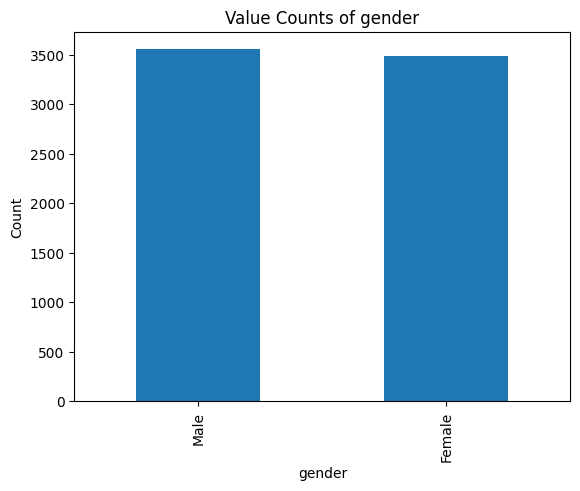

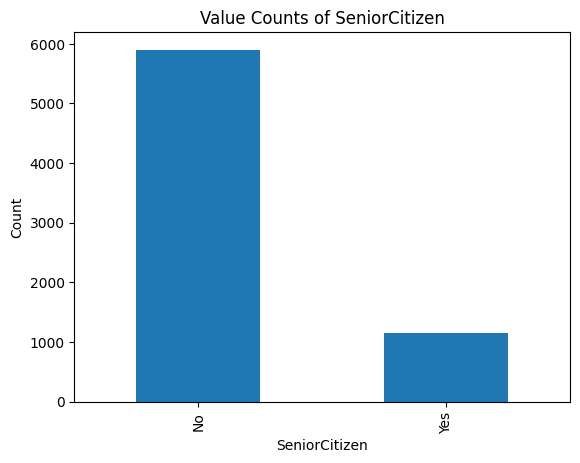

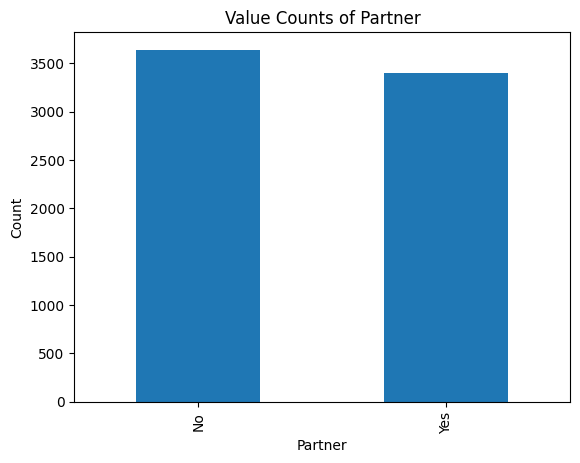

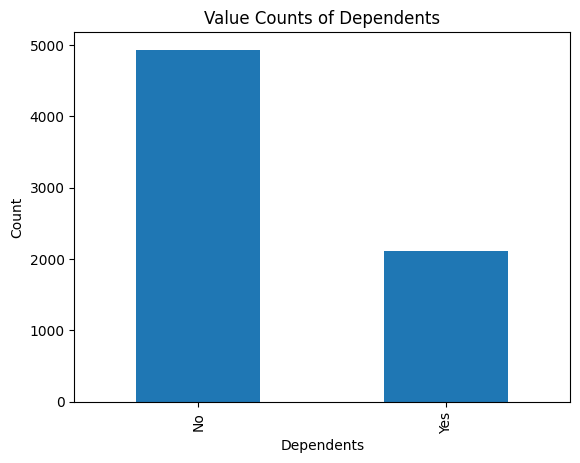

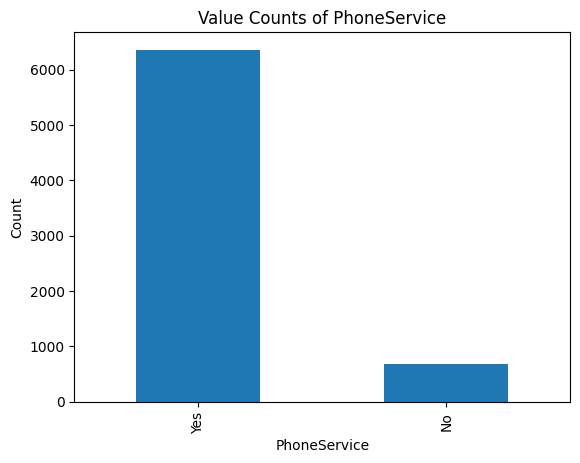

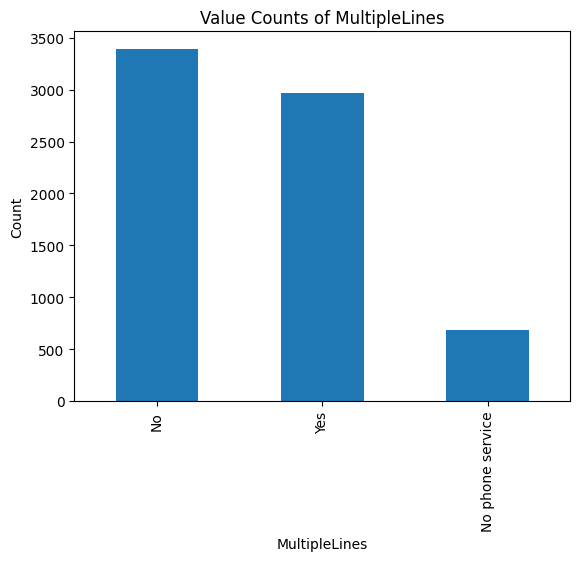

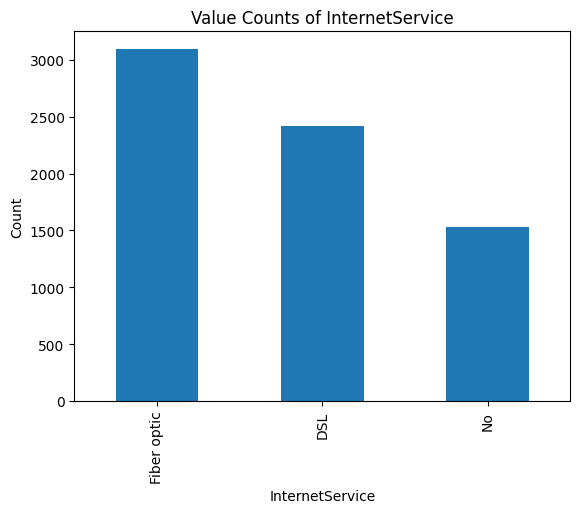

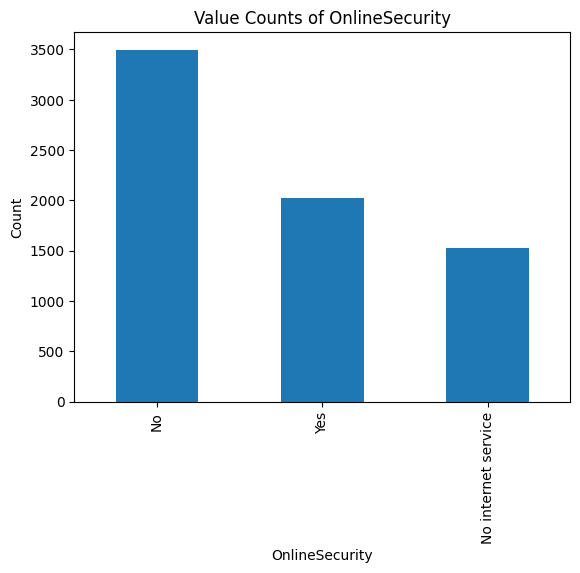

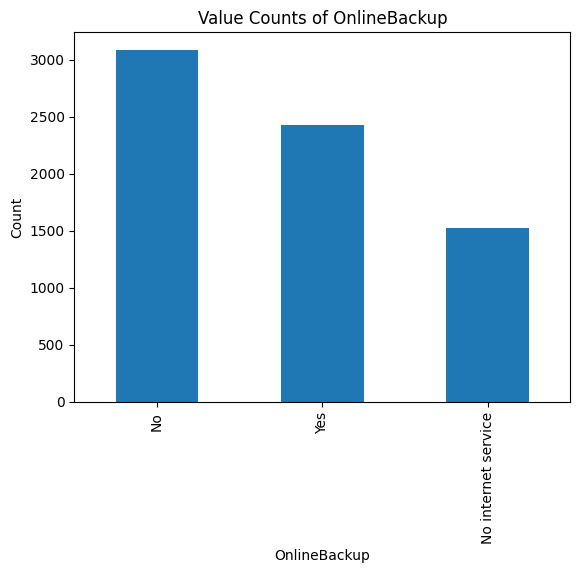

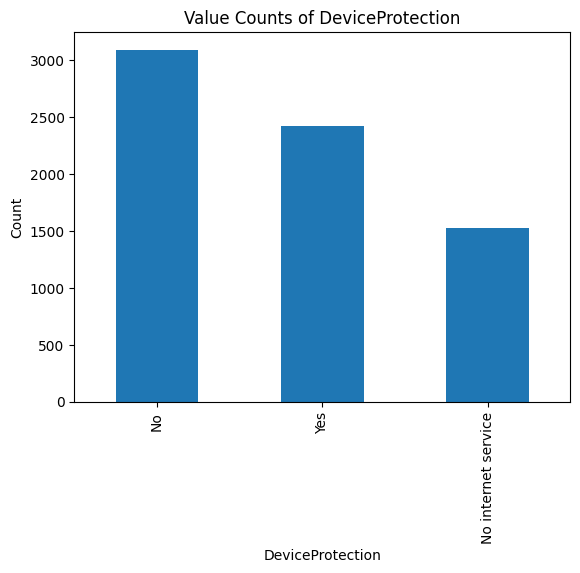

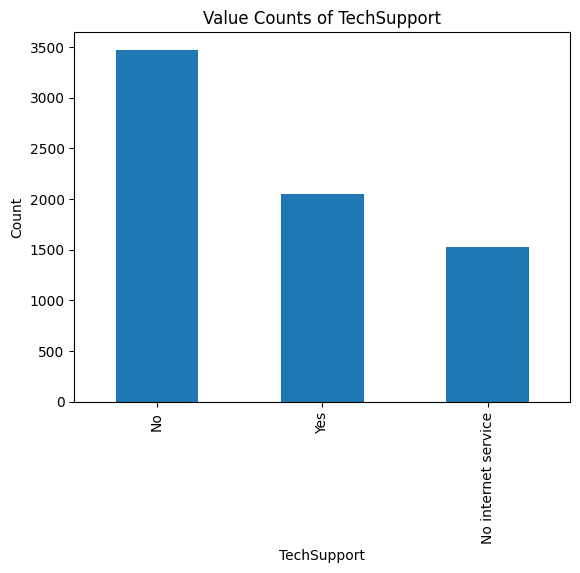

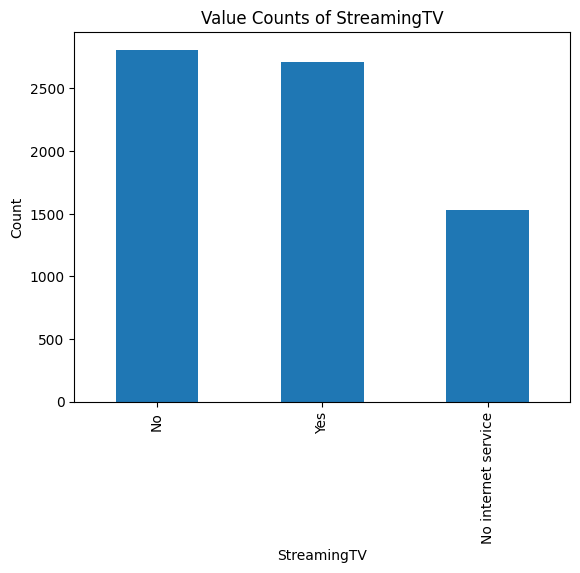

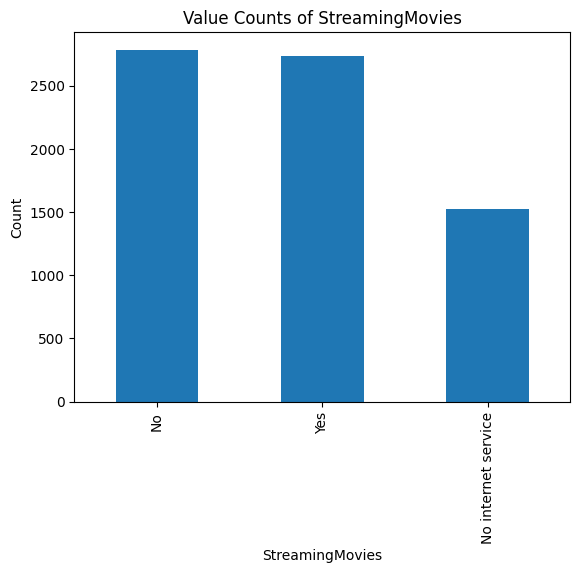

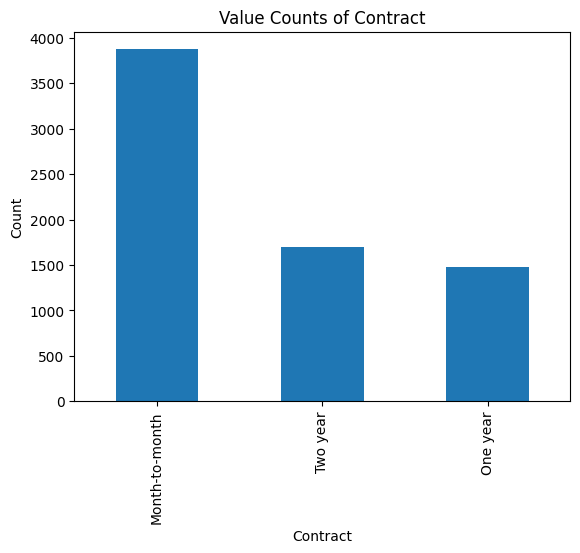

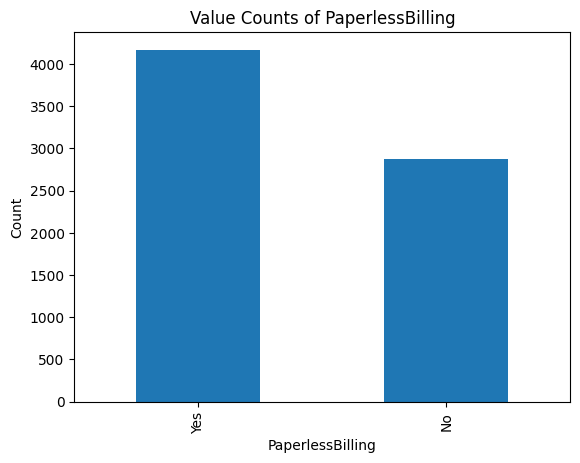

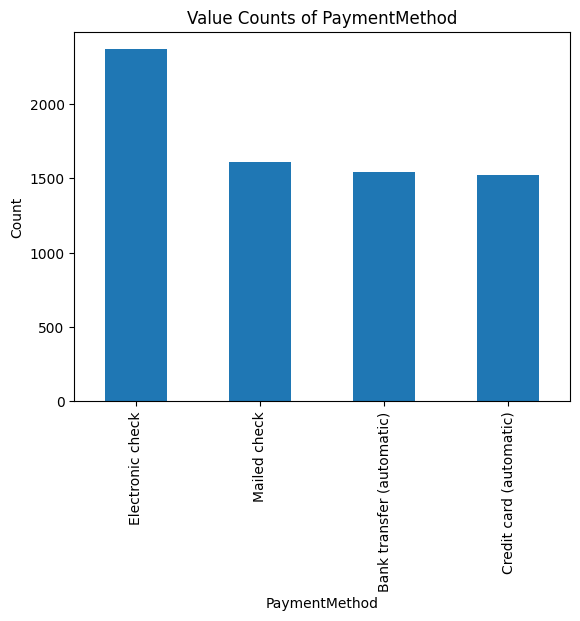

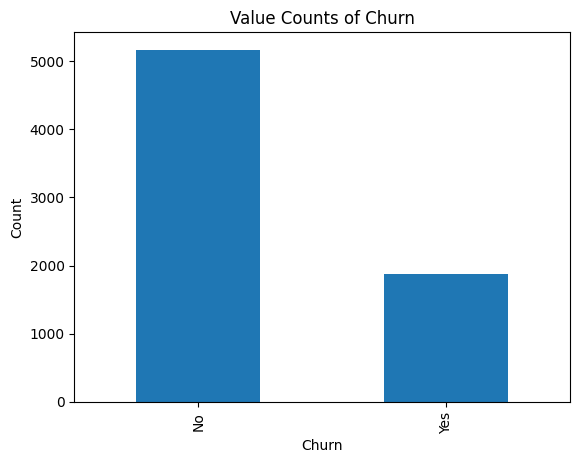

In [62]:
for col in customers.columns:
    if customers[col].nunique() < 5:
        customers[col].value_counts().plot(kind='bar')
        plt.title(f"Value Counts of {col}")
        plt.xlabel(col)
        plt.ylabel('Count')
        plt.show()  # Important to show each plot properly


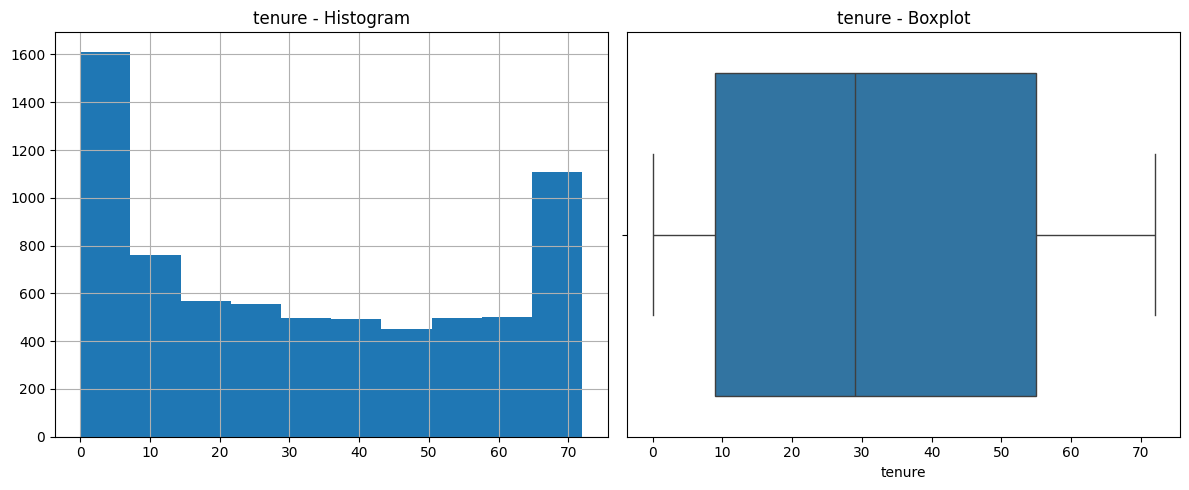

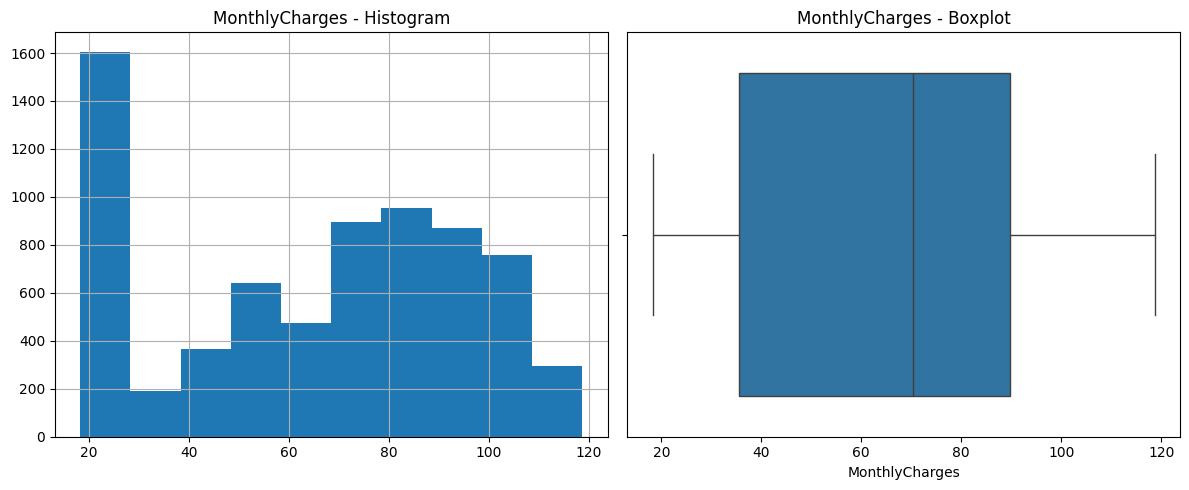

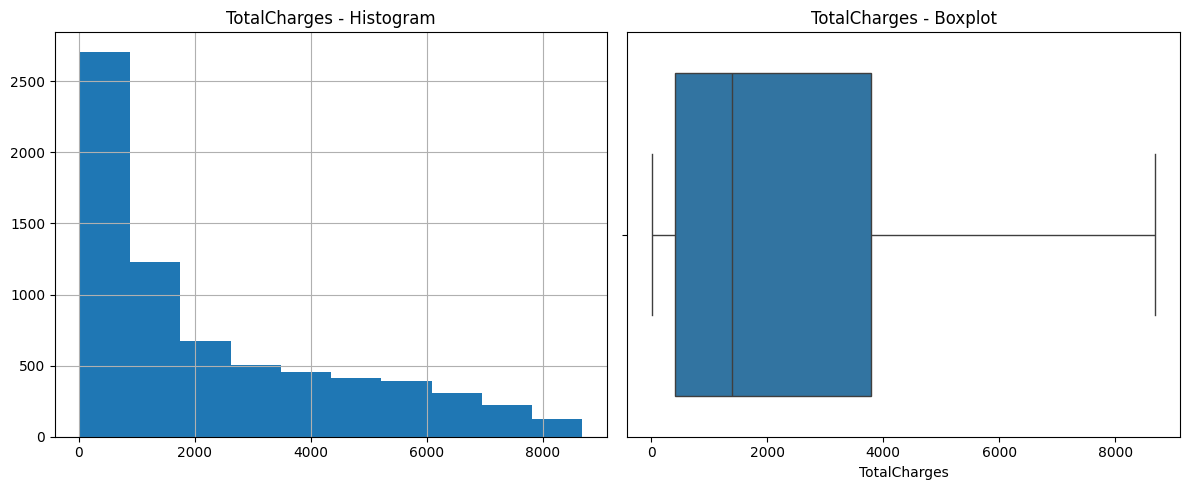

In [63]:
for col in customers.columns:
    if customers[col].dtype != 'object':  # Only numeric columns
        plt.figure(figsize=(12, 5))

        # Histogram
        plt.subplot(1, 2, 1)
        customers[col].hist()
        plt.title(f'{col} - Histogram')

        # Boxplot
        plt.subplot(1, 2, 2)
        sns.boxplot(x=customers[col])
        plt.title(f'{col} - Boxplot')

        plt.tight_layout()
        plt.show()

In [64]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

customers_copy = customers.copy()  # Keep original safe

# 1. Binary columns (Yes/No → 1/0)
binary_cols = [col for col in customers_copy.columns if customers_copy[col].nunique() == 2]
for col in binary_cols:
    customers_copy[col] = customers_copy[col].map({'Yes': 1, 'No': 0, 'Female': 0, 'Male': 1})  # Adjusted for gender too

# 2. One-hot encoding for multi-category columns (3-10 unique values)
categorical_cols = [col for col in customers_copy.columns if 2 < customers_copy[col].nunique() < 10 and customers_copy[col].dtype == 'object']
customers_copy = pd.get_dummies(customers_copy, columns=categorical_cols, drop_first=True)

# 3. MinMax Scaling for numeric columns
numeric_cols = customers_copy.select_dtypes(include=['int64', 'float64']).columns
scaler = MinMaxScaler()
customers_copy[numeric_cols] = scaler.fit_transform(customers_copy[numeric_cols])

customers_copy.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0.0,1.0,0.0,0.013889,0.0,1.0,0.115423,0.001275,0.0,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False
1,1.0,0.0,0.0,0.0,0.472222,1.0,0.0,0.385075,0.215867,0.0,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True
2,1.0,0.0,0.0,0.0,0.027778,1.0,1.0,0.354229,0.010310,1.0,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
3,1.0,0.0,0.0,0.0,0.625000,0.0,0.0,0.239303,0.210241,0.0,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False
4,0.0,0.0,0.0,0.0,0.027778,1.0,1.0,0.521891,0.015330,1.0,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False


In [65]:
customers.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')